# پیش‌بینی احتمال خروج مشتری بانک با استفاده از XGBoost

## هدف پروژه
این نوت‌بوک برای پیش‌بینی احتمال خروج مشتریان بانک و ارائه راهکارهای Win-Back طراحی شده است.

### مراحل کار:
1. بارگذاری و بررسی داده‌ها
2. پیش‌پردازش و مهندسی ویژگی
3. آموزش مدل XGBoost
4. ارزیابی مدل
5. پیش‌بینی احتمال خروج
6. ارائه راهکارهای Win-Back


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)

# XGBoost
import xgboost as xgb

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("✅ تمام کتابخانه‌ها با موفقیت بارگذاری شدند!")


✅ تمام کتابخانه‌ها با موفقیت بارگذاری شدند!


## 1. بارگذاری و بررسی داده‌ها


In [5]:
# Load the dataset
df = pd.read_csv(r'd:\دیتاست\Bank Customer Churn Prediction.csv')

print(f"📊 ابعاد دیتاست: {df.shape}")
print(f"\n📋 نام ستون‌ها:")
print(df.columns.tolist())
print(f"\n🔍 اطلاعات اولیه:")
df.head(10)


📊 ابعاد دیتاست: (10000, 12)

📋 نام ستون‌ها:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

🔍 اطلاعات اولیه:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [6]:
# Basic information about the dataset
print("📊 اطلاعات کلی دیتاست:")
print(df.info())
print("\n" + "="*60)
print("\n📈 آمار توصیفی:")
df.describe()


📊 اطلاعات کلی دیتاست:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


📈 آمار توصیفی:


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
# Check for missing values
print("🔍 بررسی مقادیر گمشده:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])
if missing_df[missing_df['Missing Count'] > 0].empty:
    print("✅ هیچ مقدار گمشده‌ای وجود ندارد!")

print("\n" + "="*60)
print("\n🔢 بررسی توزیع متغیر هدف (Churn):")
churn_dist = df['churn'].value_counts()
churn_percent = df['churn'].value_counts(normalize=True) * 100
print(f"\nتعداد مشتریان باقی‌مانده: {churn_dist[0]} ({churn_percent[0]:.2f}%)")
print(f"تعداد مشتریان خروج کرده: {churn_dist[1]} ({churn_percent[1]:.2f}%)")


🔍 بررسی مقادیر گمشده:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []
✅ هیچ مقدار گمشده‌ای وجود ندارد!


🔢 بررسی توزیع متغیر هدف (Churn):

تعداد مشتریان باقی‌مانده: 7963 (79.63%)
تعداد مشتریان خروج کرده: 2037 (20.37%)


## 2. تجسم و تحلیل داده‌ها


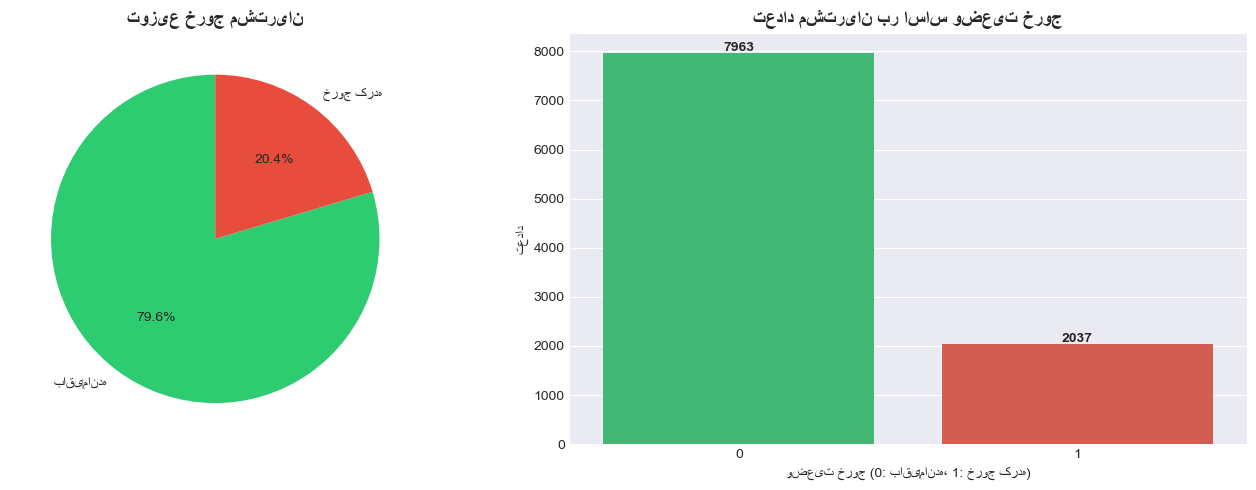

In [8]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = df['churn'].value_counts()
axes[0].pie(churn_counts.values, labels=['باقی‌مانده', 'خروج کرده'], 
            autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
axes[0].set_title('توزیع خروج مشتریان', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=df, x='churn', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('تعداد مشتریان بر اساس وضعیت خروج', fontsize=14, fontweight='bold')
axes[1].set_xlabel('وضعیت خروج (0: باقی‌مانده، 1: خروج کرده)')
axes[1].set_ylabel('تعداد')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


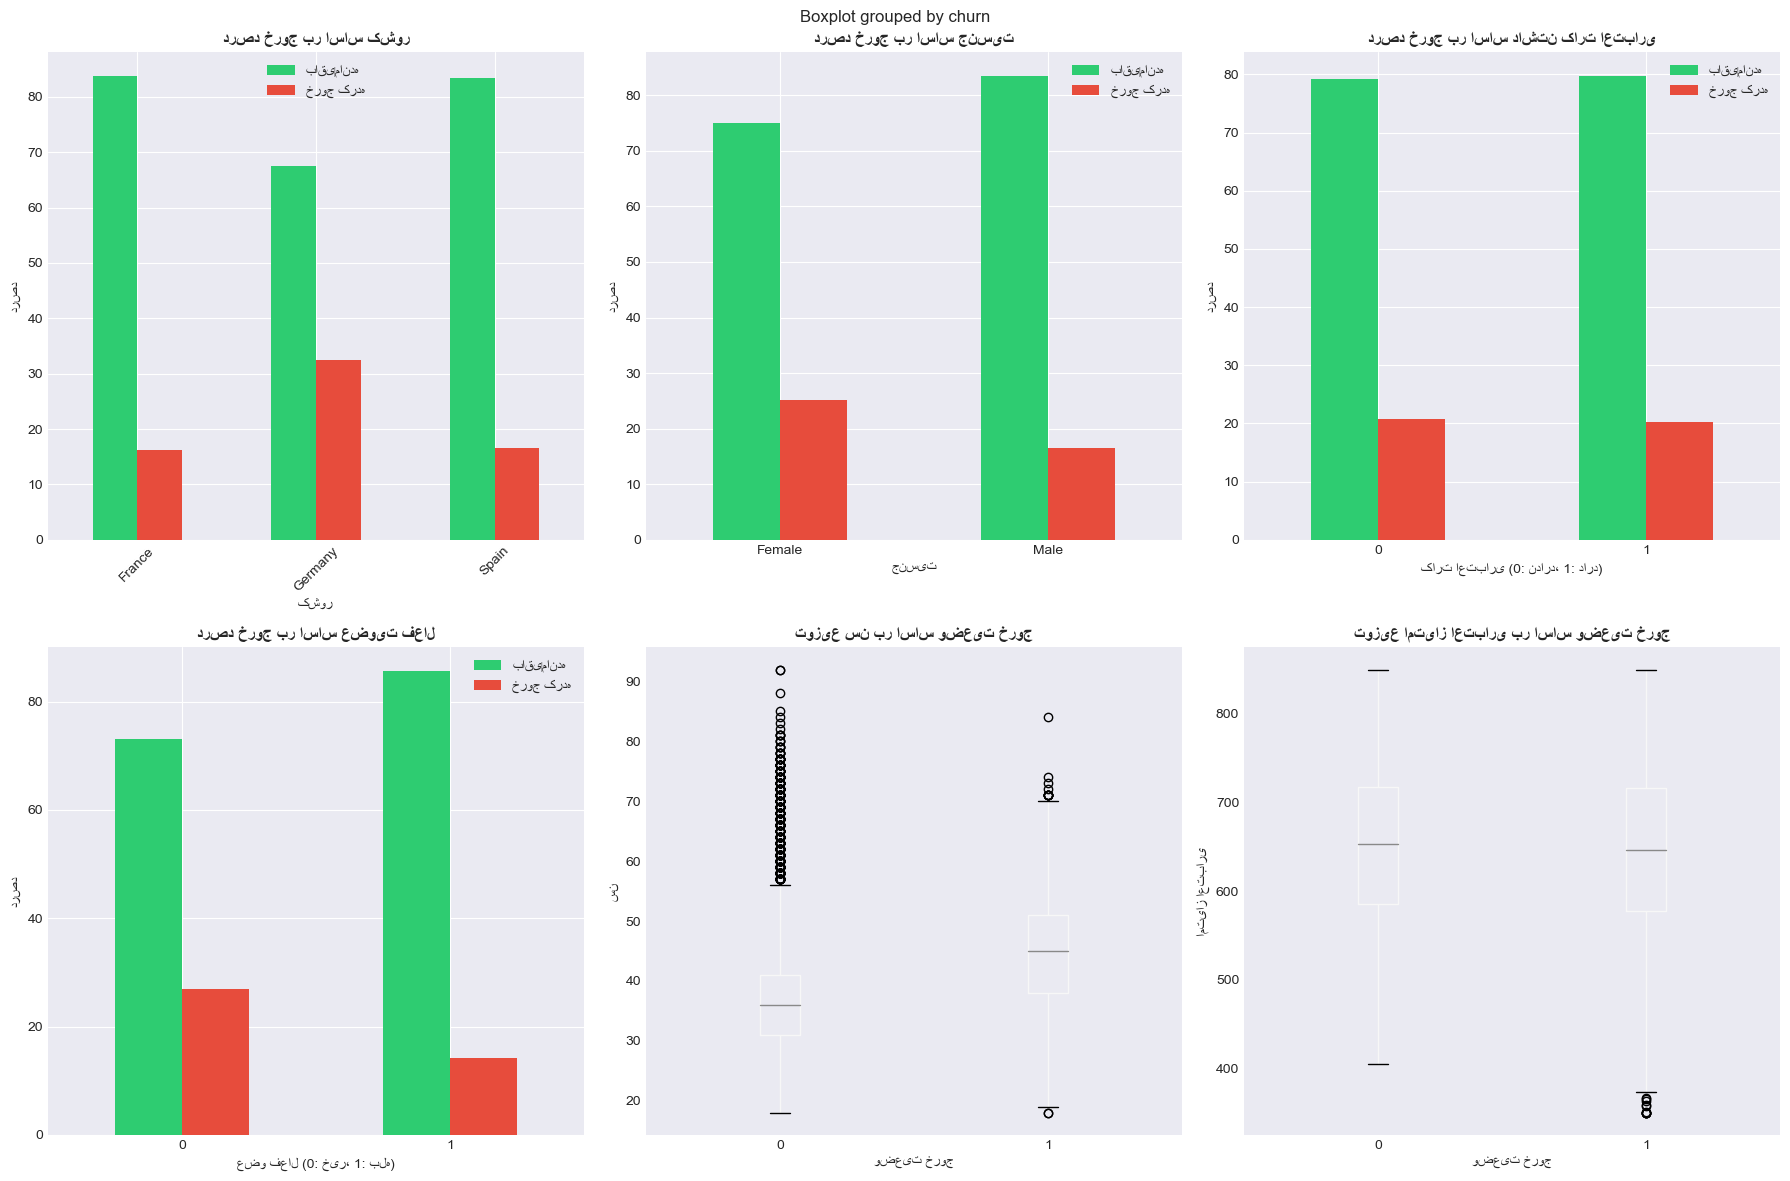

In [ ]:
# Analyze churn by different features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Churn by Country
country_churn = pd.crosstab(df['country'], df['churn'], normalize='index') * 100
country_churn.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('درصد خروج بر اساس کشور', fontweight='bold')
axes[0, 0].set_xlabel('کشور')
axes[0, 0].set_ylabel('درصد')
axes[0, 0].legend(['باقی‌مانده', 'خروج کرده'])
axes[0, 0].tick_params(axis='x', rotation=45)

# Churn by Gender
gender_churn = pd.crosstab(df['gender'], df['churn'], normalize='index') * 100
gender_churn.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('درصد خروج بر اساس جنسیت', fontweight='bold')
axes[0, 1].set_xlabel('جنسیت')
axes[0, 1].set_ylabel('درصد')
axes[0, 1].legend(['باقی‌مانده', 'خروج کرده'])
axes[0, 1].tick_params(axis='x', rotation=0)

# Churn by Credit Card
card_churn = pd.crosstab(df['credit_card'], df['churn'], normalize='index') * 100
card_churn.plot(kind='bar', ax=axes[0, 2], color=['#2ecc71', '#e74c3c'])
axes[0, 2].set_title('درصد خروج بر اساس داشتن کارت اعتباری', fontweight='bold')
axes[0, 2].set_xlabel('کارت اعتباری (0: ندارد، 1: دارد)')
axes[0, 2].set_ylabel('درصد')
axes[0, 2].legend(['باقی‌مانده', 'خروج کرده'])
axes[0, 2].tick_params(axis='x', rotation=0)

# Churn by Active Member
active_churn = pd.crosstab(df['active_member'], df['churn'], normalize='index') * 100
active_churn.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('درصد خروج بر اساس عضویت فعال', fontweight='bold')
axes[1, 0].set_xlabel('عضو فعال (0: خیر، 1: بله)')
axes[1, 0].set_ylabel('درصد')
axes[1, 0].legend(['باقی‌مانده', 'خروج کرده'])
axes[1, 0].tick_params(axis='x', rotation=0)

# Age distribution by churn
df.boxplot(column='age', by='churn', ax=axes[1, 1], grid=False)
axes[1, 1].set_title('توزیع سن بر اساس وضعیت خروج', fontweight='bold')
axes[1, 1].set_xlabel('وضعیت خروج')
axes[1, 1].set_ylabel('سن')

# Credit Score distribution by churn
df.boxplot(column='credit_score', by='churn', ax=axes[1, 2], grid=False)
axes[1, 2].set_title('توزیع امتیاز اعتباری بر اساس وضعیت خروج', fontweight='bold')
axes[1, 2].set_xlabel('وضعیت خروج')
axes[1, 2].set_ylabel('امتیاز اعتباری')

plt.tight_layout()
plt.show()
# سن بالاتر → احتمال خروج بیشتر
# امتیاز اعتباری بالاتر → احتمال خروج کمتر

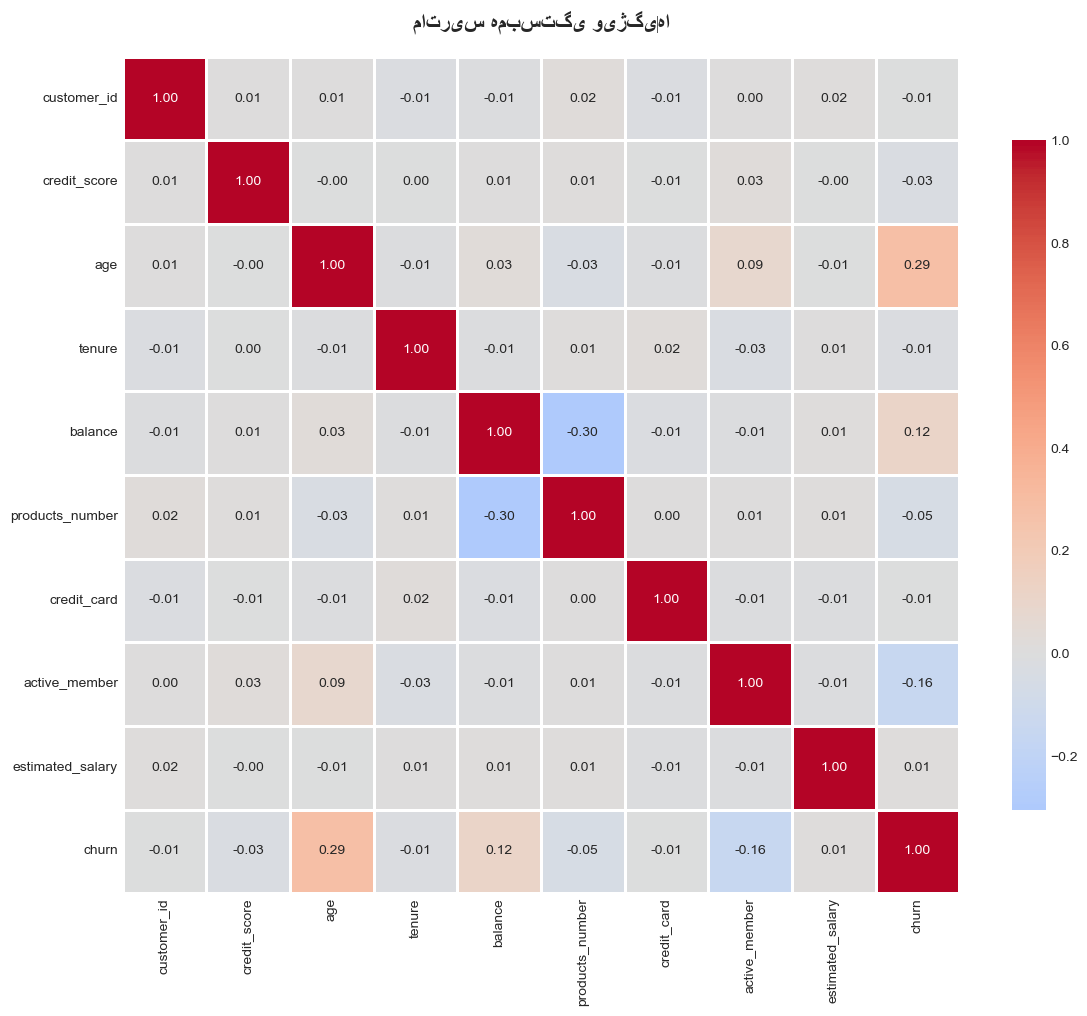


🔗 همبستگی ویژگی‌ها با خروج مشتری:
churn               1.000000
age                 0.285323
balance             0.118533
estimated_salary    0.012097
customer_id        -0.006248
credit_card        -0.007138
tenure             -0.014001
credit_score       -0.027094
products_number    -0.047820
active_member      -0.156128
Name: churn, dtype: float64


In [9]:
# Correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('ماتریس همبستگی ویژگی‌ها', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show correlation with churn
print("\n🔗 همبستگی ویژگی‌ها با خروج مشتری:")
churn_corr = correlation_matrix['churn'].sort_values(ascending=False)
print(churn_corr)


## 3. پیش‌پردازش و مهندسی ویژگی


In [10]:
# Create a copy for preprocessing
df_processed = df.copy()

# Save customer_id for later use
customer_ids = df_processed['customer_id'].copy()

# Feature Engineering
print("🔧 ایجاد ویژگی‌های جدید...")

# 1. Balance to Salary Ratio
df_processed['balance_to_salary_ratio'] = df_processed['balance'] / (df_processed['estimated_salary'] + 1)

# 2. Age Groups
df_processed['age_group'] = pd.cut(df_processed['age'], 
                                    bins=[0, 30, 40, 50, 60, 100], 
                                    labels=['<30', '30-40', '40-50', '50-60', '60+'])

# 3. Credit Score Categories
df_processed['credit_score_category'] = pd.cut(df_processed['credit_score'],
                                                bins=[0, 580, 670, 740, 850],
                                                labels=['Poor', 'Fair', 'Good', 'Excellent'])

# 4. Tenure Groups
df_processed['tenure_group'] = pd.cut(df_processed['tenure'],
                                       bins=[-1, 2, 5, 8, 10],
                                       labels=['New', 'Short', 'Medium', 'Long'])

# 5. Products per Tenure (engagement metric)
df_processed['products_per_tenure'] = df_processed['products_number'] / (df_processed['tenure'] + 1)

# 6. Engagement Score (combination of active member, credit card, and products)
df_processed['engagement_score'] = (df_processed['active_member'] * 2 + 
                                     df_processed['credit_card'] * 1 + 
                                     df_processed['products_number'] * 0.5)

print("✅ ویژگی‌های جدید ایجاد شدند!")
print(f"\n📊 ابعاد جدید دیتاست: {df_processed.shape}")

# این ویژگی‌ها برای بهبود دقت مدل XGBoost در پیش‌بینی خروج مشتری (Churn) 
# استفاده می‌شوند و الگوهای پیچیده‌تر را نمایان می‌کنند.


🔧 ایجاد ویژگی‌های جدید...
✅ ویژگی‌های جدید ایجاد شدند!

📊 ابعاد جدید دیتاست: (10000, 18)


In [11]:
# Encode categorical variables 
print("🔤 کدگذاری متغیرهای دسته‌ای...")

# Label encoding for categorical variables
label_encoders = {}
categorical_cols = ['country', 'gender', 'age_group', 'credit_score_category', 'tenure_group']

for col in categorical_cols:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col + '_encoded'] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
        print(f"  ✓ {col} encoded")
        #  (مثلاً 'Male' → 0، 'Female' → 1)

# One-hot encoding for country and gender (alternative approach)
df_encoded = pd.get_dummies(df_processed, columns=['country', 'gender'], prefix=['country', 'gender'])

print("\n✅ کدگذاری انجام شد!")
print(f"📊 ابعاد نهایی دیتاست: {df_encoded.shape}")


🔤 کدگذاری متغیرهای دسته‌ای...
  ✓ country encoded
  ✓ gender encoded
  ✓ age_group encoded
  ✓ credit_score_category encoded
  ✓ tenure_group encoded

✅ کدگذاری انجام شد!
📊 ابعاد نهایی دیتاست: (10000, 26)


In [13]:
# Prepare features and target
# Drop unnecessary columns
columns_to_drop = ['customer_id', 'churn', 'age_group', 'credit_score_category', 'tenure_group']

# Keep only numeric and encoded features
feature_columns = [col for col in df_encoded.columns 
                   if col not in columns_to_drop and not col.endswith('_encoded')]
# ستون‌های عددی اصلی (مثل balance، age، credit_score) و ستون‌های one-hot شده 
# (مثل country_France، gender_Male)


# Add encoded columns if they exist
encoded_cols = [col for col in df_encoded.columns if col.endswith('_encoded')]
feature_columns.extend(encoded_cols)
# نتیجه: ترکیب ستون‌های عددی، one-hot و label-encoded

X = df_encoded[feature_columns]
y = df_encoded['churn']

print(f"📊 تعداد ویژگی‌ها: {len(feature_columns)}")
print(f"📊 تعداد نمونه‌ها: {len(X)}")
print(f"\n📋 لیست ویژگی‌ها:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")


📊 تعداد ویژگی‌ها: 21
📊 تعداد نمونه‌ها: 10000

📋 لیست ویژگی‌ها:
  1. credit_score
  2. age
  3. tenure
  4. balance
  5. products_number
  6. credit_card
  7. active_member
  8. estimated_salary
  9. balance_to_salary_ratio
  10. products_per_tenure
  11. engagement_score
  12. country_France
  13. country_Germany
  14. country_Spain
  15. gender_Female
  16. gender_Male
  17. country_encoded
  18. gender_encoded
  19. age_group_encoded
  20. credit_score_category_encoded
  21. tenure_group_encoded


In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 داده‌های آموزش: {X_train.shape[0]} نمونه")
print(f"📊 داده‌های تست: {X_test.shape[0]} نمونه")
print(f"\n📈 توزیع کلاس در داده‌های آموزش:")
print(y_train.value_counts())
print(f"\n📈 توزیع کلاس در داده‌های تست:")
print(y_test.value_counts())


📊 داده‌های آموزش: 8000 نمونه
📊 داده‌های تست: 2000 نمونه

📈 توزیع کلاس در داده‌های آموزش:
churn
0    6370
1    1630
Name: count, dtype: int64

📈 توزیع کلاس در داده‌های تست:
churn
0    1593
1     407
Name: count, dtype: int64


## 4. آموزش مدل XGBoost


In [15]:
# Train XGBoost model
print("🚀 آموزش مدل XGBoost...")

# Calculate scale_pos_weight for handling class imbalance - Imbalanced Data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# churn=1 => نسبت: 8000/2000 = 4
# تعداد 0 =900 # تعداد 1 = 100   scale_pos_weight = 900 / 100 = 9
# یعنی کلاس منفی ۹ برابر کلاس مثبت است.
#نمونه‌های کلاس 1 مهم‌تر هستند و باید بیشتر توجه شود.
# هرچه این عدد بزرگ‌تر باشد، مدل به کلاس مثبت (۱) اهمیت بیشتری می‌دهد.

# XGBoost parameters
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'use_label_encoder': False
}

# Create and train the model
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("✅ مدل با موفقیت آموزش داده شد!")
print(f"\n📊 وزن مقیاس برای کلاس نامتعادل: {scale_pos_weight:.2f}")

# مزایا:
# بهبود Recall: مدل بهتر مشتریان در معرض خروج را شناسایی می‌کند
# بهبود Precision: کاهش false negatives (مشتریانی که خروج می‌کنند اما پیش‌بینی نمی‌شوند)
# تعادل بهتر: مدل تمایل کمتری به پیش‌بینی کلاس اکثریت دارد
# پارامترهای منظم‌سازی (reg_alpha, reg_lambda, gamma, min_child_weight) به کنترل 
# overfitting کمک می‌کنند



🚀 آموزش مدل XGBoost...
✅ مدل با موفقیت آموزش داده شد!

📊 وزن مقیاس برای کلاس نامتعادل: 3.91


📊 مهم‌ترین ویژگی‌ها:
                    feature  importance
4           products_number    0.198518
18        age_group_encoded    0.086260
1                       age    0.073649
12          country_Germany    0.073511
6             active_member    0.066274
10         engagement_score    0.056725
17           gender_encoded    0.038110
3                   balance    0.036690
14            gender_Female    0.036140
8   balance_to_salary_ratio    0.034659
16          country_encoded    0.032781
11           country_France    0.031862
15              gender_Male    0.029523
13            country_Spain    0.028168
7          estimated_salary    0.027894


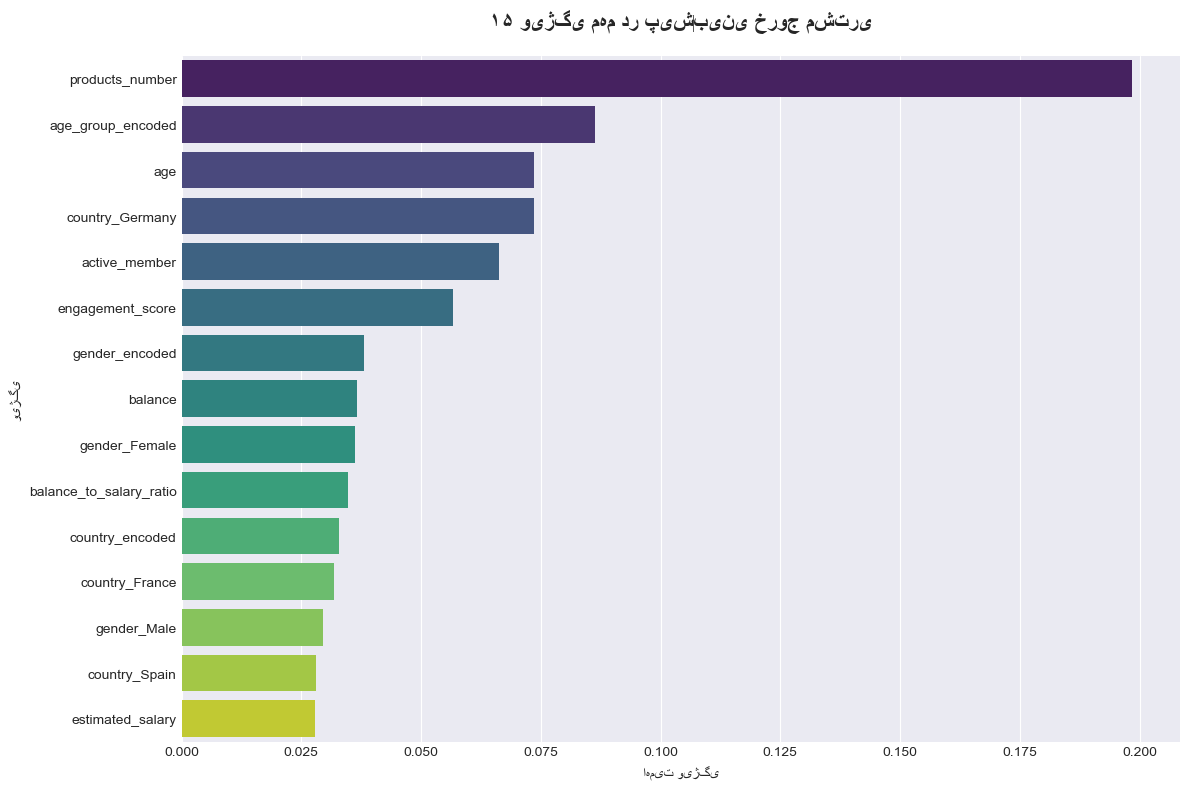

In [16]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("📊 مهم‌ترین ویژگی‌ها:")
print(feature_importance.head(15))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('۱۵ ویژگی مهم در پیش‌بینی خروج مشتری', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('اهمیت ویژگی')
plt.ylabel('ویژگی')
plt.tight_layout()
plt.show()


## 5. ارزیابی مدل


In [17]:
# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("📊 نتایج ارزیابی مدل:")
print("=" * 60)
print(f"دقت (Accuracy):     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"دقت (Precision):    {precision:.4f} ({precision*100:.2f}%)")
print(f"بازخوانی (Recall):  {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:           {f1:.4f}")
print(f"ROC-AUC:            {roc_auc:.4f} ({roc_auc*100:.2f}%)")
print("=" * 60)


📊 نتایج ارزیابی مدل:
دقت (Accuracy):     0.8255 (82.55%)
دقت (Precision):    0.5612 (56.12%)
بازخوانی (Recall):  0.6536 (65.36%)
F1-Score:           0.6039
ROC-AUC:            0.8473 (84.73%)


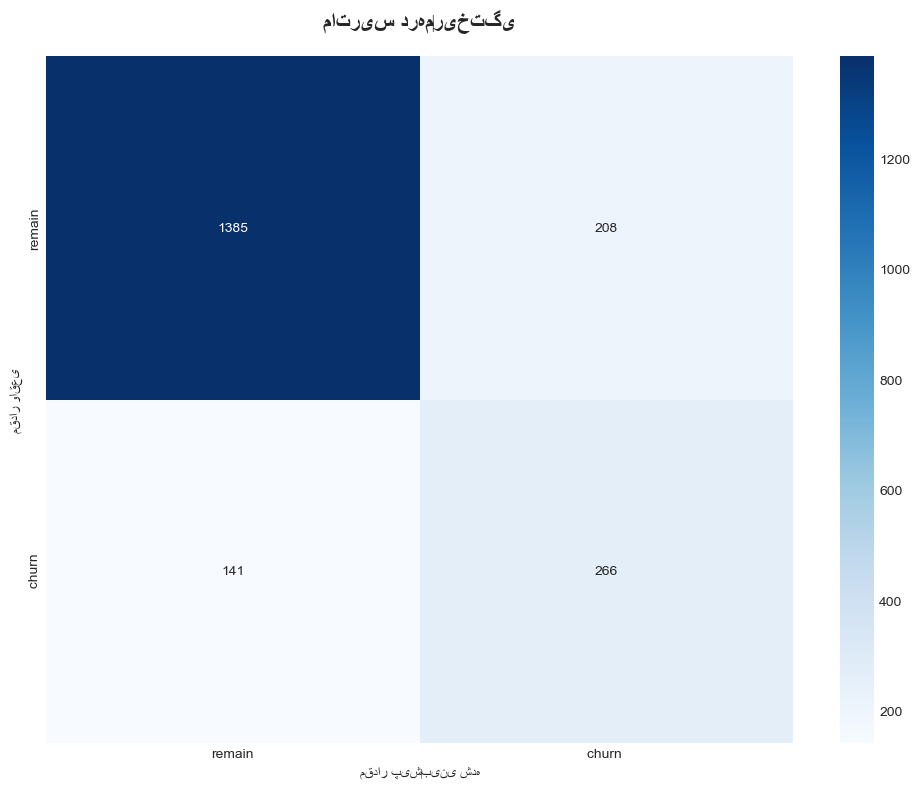


📋 گزارش طبقه‌بندی:
              precision    recall  f1-score   support

  باقی‌مانده       0.91      0.87      0.89      1593
   خروج کرده       0.56      0.65      0.60       407

    accuracy                           0.83      2000
   macro avg       0.73      0.76      0.75      2000
weighted avg       0.84      0.83      0.83      2000



In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['remain', 'churn '],
            yticklabels=['remain', ' churn'])
plt.title('ماتریس درهم‌ریختگی', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('مقدار واقعی')
plt.xlabel('مقدار پیش‌بینی شده')
plt.tight_layout()
plt.show()

print("\n📋 گزارش طبقه‌بندی:")
print(classification_report(y_test, y_pred, target_names=['باقی‌مانده', 'خروج کرده']))


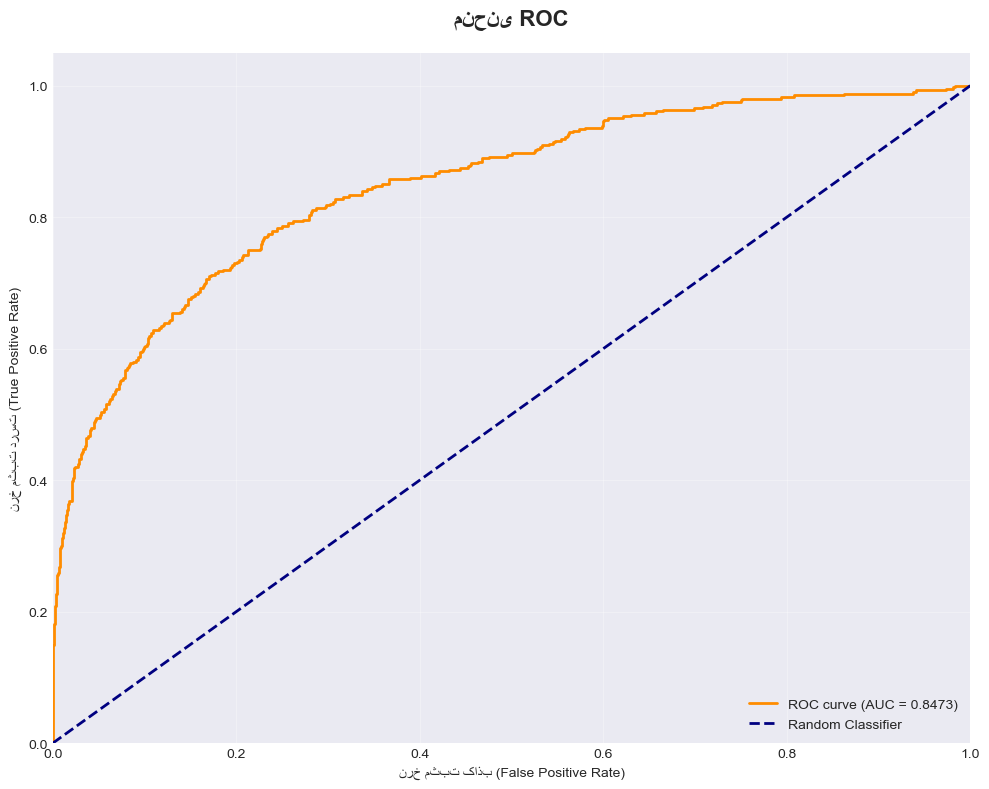

In [20]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('نرخ مثبت کاذب (False Positive Rate)')
plt.ylabel('نرخ مثبت درست (True Positive Rate)')
plt.title('منحنی ROC', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# فاصله از خط مبنا: هر چه فاصله منحنی از خط تصادفی بیشتر باشد، مدل بهتر است



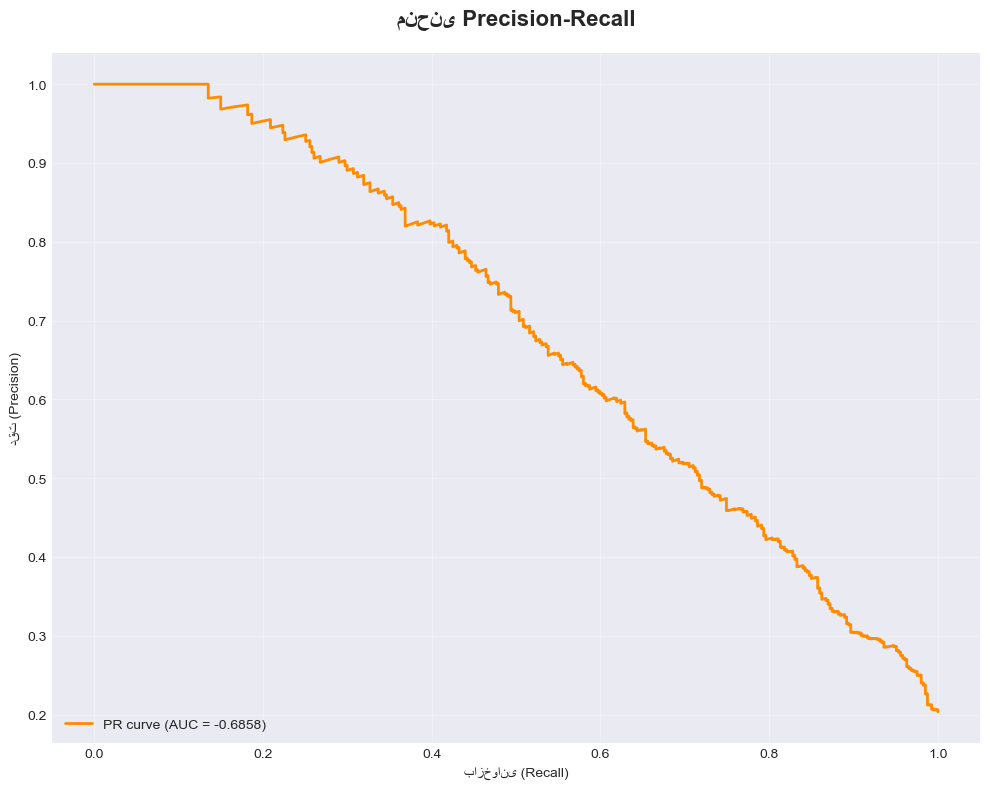

In [21]:
# Precision-Recall Curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = np.trapz(precision_curve, recall_curve)

plt.figure(figsize=(10, 8))
plt.plot(recall_curve, precision_curve, color='darkorange', lw=2, 
         label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('بازخوانی (Recall)')
plt.ylabel('دقت (Precision)')
plt.title('منحنی Precision-Recall', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. پیش‌بینی احتمال خروج مشتریان


In [62]:
# Predict churn probability for all customers
print("🔮 پیش‌بینی احتمال خروج برای تمام مشتریان...")

# Get customer IDs for test set
#**** customer_ids = df_processed['customer_id'].copy()

# این خط، ایندکس‌های ردیف‌های داده تست را ذخیره می‌کند.
#این ایندکس‌ها به رکوردهای اصلی در دیتاست اصلی اشاره دارند.
test_indices = X_test.index
test_customer_ids = customer_ids.iloc[test_indices].values
# شناسه مشتریان در داده تست
# .values به آرایه تبدیل می‌کند.
#  نگاشت نتایج پیش‌بینی به شناسه‌های مشتریان اصلی

# print(customer_ids.iloc[test_indices])
# print(customer_ids.iloc[test_indices].values)

# Predict probabilities
churn_probabilities = xgb_model.predict_proba(X_test)[:, 1]
# .predict_proba(X_test) دو ستون برمی‌گرداند:



# Create results dataframe
results_df = pd.DataFrame({
    'customer_id': test_customer_ids,
    'churn_probability': churn_probabilities,
    'predicted_churn': y_pred,
    'actual_churn': y_test.values
})

# print(results_df)
# Add risk categories
def categorize_risk(prob):
    if prob >= 0.7:
        return 'خطر بالا'
    elif prob >= 0.5:
        return 'خطر متوسط'
    elif prob >= 0.3:
        return 'خطر پایین'
    else:
        return 'خطر بسیار پایین'

results_df['risk_category'] = results_df['churn_probability'].apply(categorize_risk)

print("✅ پیش‌بینی انجام شد!")
print(f"\n📊 توزیع مشتریان بر اساس سطح خطر:")
print(results_df['risk_category'].value_counts())


🔮 پیش‌بینی احتمال خروج برای تمام مشتریان...
✅ پیش‌بینی انجام شد!

📊 توزیع مشتریان بر اساس سطح خطر:
risk_category
خطر بسیار پایین    1262
خطر بالا            304
خطر پایین           264
خطر متوسط           170
Name: count, dtype: int64


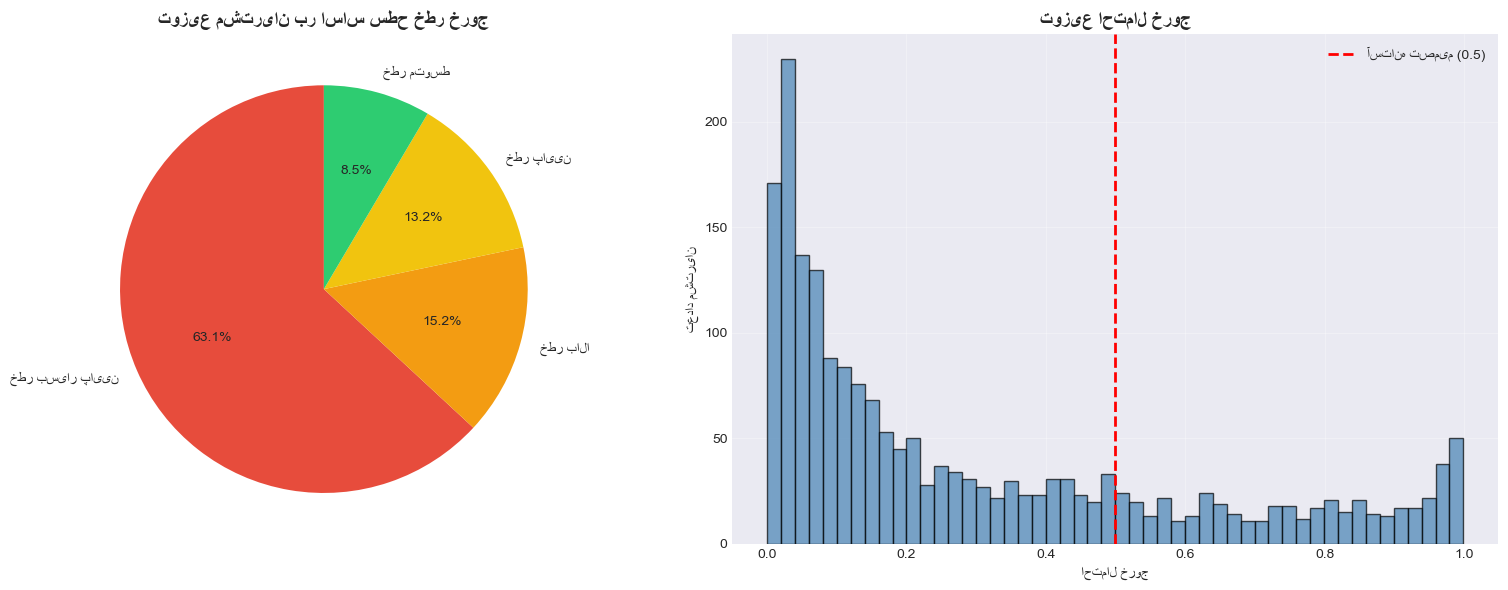

In [39]:
# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Risk category distribution
risk_counts = results_df['risk_category'].value_counts()
colors_risk = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71']
axes[0].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors_risk[:len(risk_counts)])
axes[0].set_title('توزیع مشتریان بر اساس سطح خطر خروج', fontsize=14, fontweight='bold')

# Probability distribution
axes[1].hist(results_df['churn_probability'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='آستانه تصمیم (0.5)')
axes[1].set_xlabel('احتمال خروج')
axes[1].set_ylabel('تعداد مشتریان')
axes[1].set_title('توزیع احتمال خروج', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [41]:
# Identify high-risk customers (close to churn)
high_risk_threshold = 0.5  # Customers with >50% churn probability

high_risk_customers = results_df[results_df['churn_probability'] >= high_risk_threshold].copy()
high_risk_customers = high_risk_customers.sort_values('churn_probability', ascending=False)

print(f"⚠️ تعداد مشتریان در معرض خطر خروج (احتمال ≥ {high_risk_threshold*100}%): {len(high_risk_customers)}")
print(f"📊 درصد از کل مشتریان: {len(high_risk_customers)/len(results_df)*100:.2f}%")

print("\n🔝 ۲۰ مشتری با بالاترین احتمال خروج:")
print(high_risk_customers[['customer_id', 'churn_probability', 'risk_category', 'actual_churn']].head(20))


⚠️ تعداد مشتریان در معرض خطر خروج (احتمال ≥ 50.0%): 474
📊 درصد از کل مشتریان: 23.70%

🔝 ۲۰ مشتری با بالاترین احتمال خروج:
      customer_id  churn_probability risk_category  actual_churn
860      15634551           0.999026      خطر بالا             1
338      15806808           0.998817      خطر بالا             1
1521     15779176           0.998571      خطر بالا             1
1298     15775318           0.998425      خطر بالا             1
586      15589017           0.998327      خطر بالا             1
501      15703793           0.998285      خطر بالا             1
1059     15692750           0.997927      خطر بالا             1
394      15624820           0.997785      خطر بالا             1
248      15696989           0.997603      خطر بالا             1
1275     15750335           0.996777      خطر بالا             1
94       15786196           0.995933      خطر بالا             1
927      15655082           0.995735      خطر بالا             1
1122     15623107           0.995

In [42]:
# Merge with original data to get customer details
high_risk_details = high_risk_customers.merge(
    df[['customer_id', 'age', 'country', 'gender', 'balance', 'credit_score', 
        'products_number', 'active_member', 'credit_card', 'estimated_salary']],
    on='customer_id',
    how='left'
)

print("📋 مشخصات مشتریان در معرض خطر:")
print(f"\n📊 آمار توصیفی:")
print(high_risk_details[['age', 'balance', 'credit_score', 'products_number', 
                          'estimated_salary', 'churn_probability']].describe())


📋 مشخصات مشتریان در معرض خطر:

📊 آمار توصیفی:
              age        balance  credit_score  products_number  \
count  474.000000     474.000000    474.000000       474.000000   
mean    45.782700   89371.251878    645.789030         1.411392   
std      8.579268   58541.176974     95.985848         0.778651   
min     22.000000       0.000000    351.000000         1.000000   
25%     40.000000   10228.887500    585.250000         1.000000   
50%     46.000000  108337.455000    644.000000         1.000000   
75%     51.000000  131069.720000    713.750000         1.750000   
max     70.000000  250898.090000    850.000000         4.000000   

       estimated_salary  churn_probability  
count        474.000000         474.000000  
mean      102848.830042           0.775359  
std        58136.697227           0.158767  
min          236.450000           0.500092  
25%        55807.710000           0.634247  
50%       101626.315000           0.791032  
75%       152401.677500           0

## 7. راهکارهای Win-Back (بازگرداندن مشتری)


In [44]:
# Define win-back strategies based on customer characteristics
def recommend_winback_strategy(row):
    """
    توصیه راهکار Win-Back بر اساس ویژگی‌های مشتری
    """
    strategies = []
    prob = row['churn_probability']
    
    # High probability customers need immediate action
    if prob >= 0.7:
        strategies.append("🚨 اقدام فوری: تماس مستقیم با مشتری")
        strategies.append("💰 پیشنهاد تخفیف ویژه یا پاداش")
    
    # Check specific characteristics
    if row.get('active_member', 0) == 0:
        strategies.append("📱 فعال‌سازی: ارسال پیامک/ایمیل برای فعال‌سازی مجدد")
        strategies.append("🎁 پیشنهاد محصول جدید برای افزایش تعامل")
    
    if row.get('credit_card', 0) == 0:
        strategies.append("💳 پیشنهاد کارت اعتباری با شرایط ویژه")
    
    if row.get('products_number', 0) <= 1:
        strategies.append("📦 پیشنهاد محصولات اضافی با تخفیف")
    
    if row.get('balance', 0) == 0:
        strategies.append("💵 پیشنهاد حساب پس‌انداز با سود بالاتر")
    
    if row.get('credit_score', 700) < 600:
        strategies.append("🔧 مشاوره مالی برای بهبود امتیاز اعتباری")
    
    if row.get('age', 0) > 50:
        strategies.append("👴 پیشنهاد محصولات ویژه برای سنین بالا")
    
    # Country-specific strategies
    country = row.get('country', '')
    if country == 'Germany':
        strategies.append("🇩🇪 پیشنهادات ویژه برای مشتریان آلمانی")
    elif country == 'France':
        strategies.append("🇫🇷 پیشنهادات ویژه برای مشتریان فرانسوی")
    elif country == 'Spain':
        strategies.append("🇪🇸 پیشنهادات ویژه برای مشتریان اسپانیایی")
    
    if not strategies:
        strategies.append("📞 تماس برای دریافت بازخورد و بهبود خدمات")
    
    return " | ".join(strategies[:5])  # Return top 5 strategies

# Apply win-back strategies
high_risk_details['winback_strategy'] = high_risk_details.apply(recommend_winback_strategy, axis=1)

print("✅ راهکارهای Win-Back برای مشتریان در معرض خطر تعیین شد!")


✅ راهکارهای Win-Back برای مشتریان در معرض خطر تعیین شد!


In [46]:
# Create priority-based win-back list
winback_priority = high_risk_details[[
    'customer_id', 'churn_probability', 'risk_category', 
    'age', 'country', 'balance', 'credit_score', 
    'active_member', 'credit_card', 'products_number',
    'winback_strategy'
]].copy()

winback_priority = winback_priority.sort_values('churn_probability', ascending=False)

print("📋 لیست اولویت‌بندی شده مشتریان برای Win-Back:")
print("=" * 100)
print(winback_priority.head(30).to_string(index=False))
print("=" * 100)


📋 لیست اولویت‌بندی شده مشتریان برای Win-Back:
 customer_id  churn_probability risk_category  age country   balance  credit_score  active_member  credit_card  products_number                                                                                                                                                                                            winback_strategy
    15634551           0.999026      خطر بالا   46 Germany 115248.11           727              0            1                4    🚨 اقدام فوری: تماس مستقیم با مشتری | 💰 پیشنهاد تخفیف ویژه یا پاداش | 📱 فعال‌سازی: ارسال پیامک/ایمیل برای فعال‌سازی مجدد | 🎁 پیشنهاد محصول جدید برای افزایش تعامل | 🇩🇪 پیشنهادات ویژه برای مشتریان آلمانی
    15806808           0.998817      خطر بالا   57 Germany 112281.60           834              0            1                3    🚨 اقدام فوری: تماس مستقیم با مشتری | 💰 پیشنهاد تخفیف ویژه یا پاداش | 📱 فعال‌سازی: ارسال پیامک/ایمیل برای فعال‌سازی مجدد | 🎁 پیشنهاد محصول جدید برای افزایش تعام

In [47]:
# Analyze win-back strategies by risk category
print("📊 تحلیل راهکارهای Win-Back بر اساس سطح خطر:\n")

for risk_level in ['خطر بالا', 'خطر متوسط', 'خطر پایین']:
    risk_customers = winback_priority[winback_priority['risk_category'] == risk_level]
    if len(risk_customers) > 0:
        print(f"\n{risk_level}:")
        print(f"  تعداد مشتریان: {len(risk_customers)}")
        print(f"  میانگین احتمال خروج: {risk_customers['churn_probability'].mean():.2%}")
        
        # Most common strategies
        all_strategies = []
        for strategy in risk_customers['winback_strategy']:
            all_strategies.extend(strategy.split(' | '))
        
        strategy_counts = pd.Series(all_strategies).value_counts()
        print(f"  راهکارهای پیشنهادی:")
        for strat, count in strategy_counts.head(3).items():
            print(f"    - {strat}: {count} مشتری")


📊 تحلیل راهکارهای Win-Back بر اساس سطح خطر:


خطر بالا:
  تعداد مشتریان: 304
  میانگین احتمال خروج: 87.73%
  راهکارهای پیشنهادی:
    - 🚨 اقدام فوری: تماس مستقیم با مشتری: 304 مشتری
    - 💰 پیشنهاد تخفیف ویژه یا پاداش: 304 مشتری
    - 📱 فعال‌سازی: ارسال پیامک/ایمیل برای فعال‌سازی مجدد: 224 مشتری

خطر متوسط:
  تعداد مشتریان: 170
  میانگین احتمال خروج: 59.31%
  راهکارهای پیشنهادی:
    - 📦 پیشنهاد محصولات اضافی با تخفیف: 141 مشتری
    - 📱 فعال‌سازی: ارسال پیامک/ایمیل برای فعال‌سازی مجدد: 81 مشتری
    - 🎁 پیشنهاد محصول جدید برای افزایش تعامل: 81 مشتری


In [ ]:
# Calculate potential revenue impact
print("💰 تحلیل تأثیر مالی Win-Back:\n")

# Estimate customer lifetime value (simplified)
# Using balance and estimated_salary as proxies
winback_priority['estimated_clv'] = (
    winback_priority['balance'] * 0.1 +  # 10% of balance
    winback_priority['estimated_salary'] * 0.05  # 5% of salary
)

total_at_risk_value = winback_priority['estimated_clv'].sum()
high_risk_value = winback_priority[winback_priority['risk_category'] == 'خطر بالا']['estimated_clv'].sum()

print(f"💵 ارزش کل مشتریان در معرض خطر: ${total_at_risk_value:,.2f}")
print(f"🚨 ارزش مشتریان با خطر بالا: ${high_risk_value:,.2f}")
print(f"\n📊 اگر 50% از مشتریان در معرض خطر را حفظ کنیم:")
print(f"   ارزش حفظ شده: ${total_at_risk_value * 0.5:,.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Value by risk category
value_by_risk = winback_priority.groupby('risk_category')['estimated_clv'].sum().sort_values(ascending=False)
axes[0].bar(value_by_risk.index, value_by_risk.values, color=['#e74c3c', '#f39c12', '#f1c40f'])
axes[0].set_title('ارزش مشتریان بر اساس سطح خطر', fontsize=14, fontweight='bold')
axes[0].set_ylabel('ارزش تخمینی (دلار)')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(value_by_risk.values):
    axes[0].text(i, v + max(value_by_risk.values)*0.01, f'${v:,.0f}', ha='center', fontweight='bold')

# Probability vs CLV scatter
scatter = axes[1].scatter(winback_priority['churn_probability'], 
                          winback_priority['estimated_clv'],
                          c=winback_priority['churn_probability'],
                          cmap='RdYlGn_r', alpha=0.6, s=50)
axes[1].set_xlabel('احتمال خروج')
axes[1].set_ylabel('ارزش تخمینی مشتری (CLV)')
axes[1].set_title('احتمال خروج در مقابل ارزش مشتری', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='احتمال خروج')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [49]:
# Export results for action
print("💾 ذخیره نتایج...")

# Save high-risk customers with strategies
winback_priority.to_csv('high_risk_customers_winback.csv', index=False, encoding='utf-8-sig')
print("✅ لیست مشتریان در معرض خطر با راهکارهای Win-Back ذخیره شد: high_risk_customers_winback.csv")

# Save all predictions
all_predictions = pd.DataFrame({
    'customer_id': customer_ids.iloc[X_test.index].values,
    'churn_probability': churn_probabilities,
    'predicted_churn': y_pred,
    'actual_churn': y_test.values,
    'risk_category': results_df['risk_category'].values
})
all_predictions.to_csv('all_customer_churn_predictions.csv', index=False, encoding='utf-8-sig')
print("✅ پیش‌بینی‌های تمام مشتریان ذخیره شد: all_customer_churn_predictions.csv")

print("\n📊 خلاصه نتایج:")
print(f"  - تعداد کل مشتریان تست شده: {len(all_predictions)}")
print(f"  - مشتریان در معرض خطر (≥50%): {len(high_risk_customers)}")
print(f"  - مشتریان با خطر بالا (≥70%): {len(winback_priority[winback_priority['risk_category'] == 'خطر بالا'])}")
print(f"  - دقت مدل: {accuracy:.2%}")
print(f"  - ROC-AUC: {roc_auc:.2%}")


💾 ذخیره نتایج...
✅ لیست مشتریان در معرض خطر با راهکارهای Win-Back ذخیره شد: high_risk_customers_winback.csv
✅ پیش‌بینی‌های تمام مشتریان ذخیره شد: all_customer_churn_predictions.csv

📊 خلاصه نتایج:
  - تعداد کل مشتریان تست شده: 2000
  - مشتریان در معرض خطر (≥50%): 474
  - مشتریان با خطر بالا (≥70%): 304
  - دقت مدل: 82.55%
  - ROC-AUC: 84.73%


## 8. خلاصه و نتیجه‌گیری

### نتایج کلیدی:
1. **مدل XGBoost** با دقت بالا مشتریان در معرض خطر را شناسایی می‌کند
2. **مشتریان با احتمال خروج بالا** شناسایی و اولویت‌بندی شدند
3. **راهکارهای Win-Back شخصی‌سازی شده** برای هر مشتری ارائه شد
4. **تحلیل تأثیر مالی** نشان می‌دهد حفظ این مشتریان چقدر ارزش دارد

### توصیه‌های عملیاتی:
- **اقدام فوری**: تماس با مشتریان با خطر بالا (احتمال ≥ 70%)
- **بازاریابی هدفمند**: استفاده از راهکارهای پیشنهادی برای هر گروه
- **نظارت مداوم**: اجرای مدل به صورت دوره‌ای برای شناسایی مشتریان جدید در معرض خطر
- **بهبود مداوم**: جمع‌آوری بازخورد و بهبود مدل بر اساس نتایج Win-Back
